In [ ]:
# ============================================================
# NLP EXPERIMENT 4
# Task 2: Named Entity Recognition (NER)
# Lab Exercises - Complete Google Colab Code
# ============================================================


# ============================================================
# CELL 1: INSTALL REQUIRED LIBRARIES
# ============================================================

!pip install -q nltk spacy wordcloud matplotlib pandas

# Download the English spaCy model
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 67.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# ============================================================
# CELL 2: IMPORT LIBRARIES
# ============================================================

import string
from collections import Counter

import nltk
import spacy
import pandas as pd
import matplotlib.pyplot as plt

from nltk.corpus import gutenberg, stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud


In [ ]:
# ============================================================
# CELL 3: DOWNLOAD NLTK DATA
# ============================================================

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("gutenberg")
nltk.download("averaged_perceptron_tagger")
nltk.download("averaged_perceptron_tagger_eng")
nltk.download("maxent_ne_chunker")
nltk.download("maxent_ne_chunker_tab")
nltk.download("words")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Unzipping corpora/gutenberg.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_

True

In [ ]:
# ============================================================
# CELL 4: LOAD SPACY MODEL
# ============================================================

nlp = spacy.load("en_core_web_sm")

print("spaCy model loaded successfully!")

spaCy model loaded successfully!


In [ ]:

# ============================================================
# TASK 1
# CUSTOM CORPUS INGESTION
#
# Question:
# Load a custom .txt file, calculate Type-Token Ratio (TTR),
# and display the Top 15 words.
# ============================================================


# ============================================================
# CELL 5: UPLOAD YOUR TEXT FILE
# ============================================================

from google.colab import files

print("Upload your .txt file:")
uploaded = files.upload()


# ============================================================
# CELL 6: READ THE UPLOADED TEXT FILE
# ============================================================

# Get the name of the uploaded file
file_name = list(uploaded.keys())[0]

# Open and read the file
with open(file_name, "r", encoding="utf-8") as file:
    custom_text = file.read()

print("File loaded successfully!")
print("\nFile name:", file_name)

print("\nFirst 500 characters:")
print("-" * 60)
print(custom_text[:500])

Upload your .txt file:


Saving bbc-text.csv to bbc-text.csv
File loaded successfully!

File name: bbc-text.csv

First 500 characters:
------------------------------------------------------------
category,text
tech,tv future in the hands of viewers with home theatre systems  plasma high-definition tvs  and digital video recorders moving into the living room  the way people watch tv will be radically different in five years  time.  that is according to an expert panel which gathered at the annual consumer electronics show in las vegas to discuss how these new technologies will impact one of our favourite pastimes. with the us leading the trend  programmes and other content will be deliver


Total tokens: 921953
Total words after cleaning: 840974
Total Tokens: 840974
Unique Words (Types): 27405
Type-Token Ratio (TTR): 0.0326

Top 15 Most Frequent Words
----------------------------------------
Word  Frequency
 the      52604
  to      25002
  of      19970
 and      18572
   a      18282
  in      17629
   s       9049
 for       8918
  is       8555
that       8255
  it       7892
  on       7537
said       7254
 was       6028
  he       5936


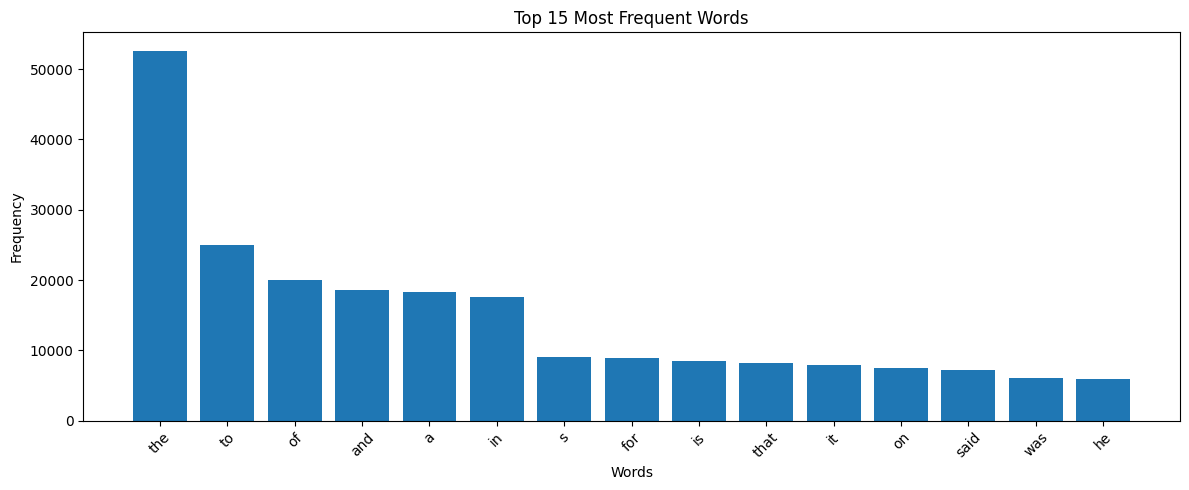

In [ ]:
# ============================================================
# CELL 7: TOKENIZE AND CLEAN THE CUSTOM CORPUS
# ============================================================

# Convert text into individual tokens
tokens = word_tokenize(custom_text)

# Convert everything to lowercase
tokens_lower = [word.lower() for word in tokens]

# Remove punctuation and keep only alphabetic words
cleaned_words = [
    word
    for word in tokens_lower
    if word.isalpha()
]

print("Total tokens:", len(tokens))
print("Total words after cleaning:", len(cleaned_words))


# ============================================================
# CELL 8: CALCULATE TYPE-TOKEN RATIO (TTR)
# ============================================================

# Token = every word occurrence
total_tokens = len(cleaned_words)

# Type = unique words
unique_words = len(set(cleaned_words))

# Type-Token Ratio
if total_tokens > 0:
    ttr = unique_words / total_tokens
else:
    ttr = 0

print("Total Tokens:", total_tokens)
print("Unique Words (Types):", unique_words)
print("Type-Token Ratio (TTR):", round(ttr, 4))


# ============================================================
# CELL 9: TOP 15 MOST FREQUENT WORDS
# ============================================================

# Count the frequency of every word
word_frequency = Counter(cleaned_words)

# Get the 15 most common words
top_15 = word_frequency.most_common(15)

# Convert the result into a DataFrame
df_top15 = pd.DataFrame(
    top_15,
    columns=["Word", "Frequency"]
)

print("\nTop 15 Most Frequent Words")
print("-" * 40)

print(df_top15.to_string(index=False))


# ============================================================
# CELL 10: BAR CHART FOR TOP 15 WORDS
# ============================================================

plt.figure(figsize=(12, 5))

plt.bar(
    df_top15["Word"],
    df_top15["Frequency"]
)

plt.title("Top 15 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



In [ ]:
# ============================================================
# TASK 2
# DOMAIN-SPECIFIC STOPWORD FILTERING
#
# Question:
# Add custom/domain-specific stopwords such as:
# said, would, could, mr
#
# Recalculate word frequencies, generate a new Word Cloud,
# and compare the changes.
# ============================================================


# ============================================================
# CELL 11: ORIGINAL STOPWORDS
# ============================================================

# Load standard English stopwords
standard_stopwords = set(stopwords.words("english"))

print("Number of standard stopwords:",
      len(standard_stopwords))


# ============================================================
# CELL 12: ADD DOMAIN-SPECIFIC STOPWORDS
# ============================================================

# Custom stopwords provided in the experiment
custom_stopwords = {
    "said",
    "would",
    "could",
    "mr"
}

# Combine standard + custom stopwords
domain_stopwords = standard_stopwords.union(custom_stopwords)

print("Custom stopwords:")
print(custom_stopwords)

print("\nTotal stopwords after adding custom words:",
      len(domain_stopwords))


# ============================================================
# CELL 13: FREQUENCY BEFORE CUSTOM STOPWORDS
# ============================================================

# Remove only standard stopwords
words_before_custom = [
    word
    for word in cleaned_words
    if word not in standard_stopwords
]

frequency_before = Counter(words_before_custom)

top_before = frequency_before.most_common(15)

df_before = pd.DataFrame(
    top_before,
    columns=["Word", "Frequency"]
)

print("Top 15 Words BEFORE Domain-Specific Stopword Filtering")
print("-" * 55)

print(df_before.to_string(index=False))



Number of standard stopwords: 198
Custom stopwords:
{'could', 'said', 'would', 'mr'}

Total stopwords after adding custom words: 202
Top 15 Words BEFORE Domain-Specific Stopword Filtering
-------------------------------------------------------
      Word  Frequency
      said       7254
        mr       2994
     would       2577
      also       2156
    people       2044
       new       1970
        us       1932
      year       1829
       one       1763
     could       1511
      last       1381
     first       1282
     world       1186
       two       1181
government       1154


In [16]:
# ============================================================
# CELL 14: FREQUENCY AFTER CUSTOM STOPWORDS
# ============================================================

# Remove both standard and custom stopwords
words_after_custom = [
    word
    for word in cleaned_words
    if word not in domain_stopwords
]

frequency_after = Counter(words_after_custom)

top_after = frequency_after.most_common(15)

df_after = pd.DataFrame(
    top_after,
    columns=["Word", "Frequency"]
)

print("Top 15 Words AFTER Domain-Specific Stopword Filtering")
print("-" * 55)

print(df_after.to_string(index=False))


# ============================================================
# CELL 15: COMPARE BEFORE AND AFTER
# ============================================================

print("COMPARISON")
print("=" * 60)

print("Words before custom filtering:",
      len(words_before_custom))

print("Words after custom filtering:",
      len(words_after_custom))

print("Words removed:",
      len(words_before_custom) - len(words_after_custom))


# Check which custom stopwords were actually present
print("\nCustom stopwords found in the corpus:")

for word in custom_stopwords:

    count = frequency_before.get(word, 0)

    print(word, ":", count)



Top 15 Words AFTER Domain-Specific Stopword Filtering
-------------------------------------------------------
      Word  Frequency
      also       2156
    people       2044
       new       1970
        us       1932
      year       1829
       one       1763
      last       1381
     first       1282
     world       1186
       two       1181
government       1154
      time       1147
        uk       1079
     years       1002
      make        927
COMPARISON
Words before custom filtering: 470883
Words after custom filtering: 456547
Words removed: 14336

Custom stopwords found in the corpus:
could : 1511
said : 7254
would : 2577
mr : 2994


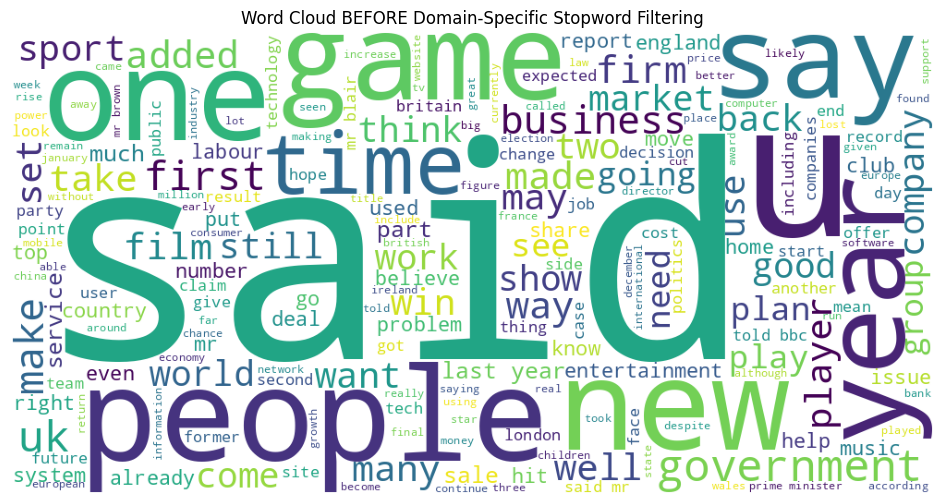

In [17]:
# ============================================================
# CELL 16: WORD CLOUD BEFORE FILTERING
# ============================================================

text_before = " ".join(words_before_custom)

wordcloud_before = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text_before)

plt.figure(figsize=(12, 6))

plt.imshow(wordcloud_before)

plt.axis("off")

plt.title("Word Cloud BEFORE Domain-Specific Stopword Filtering")

plt.show()

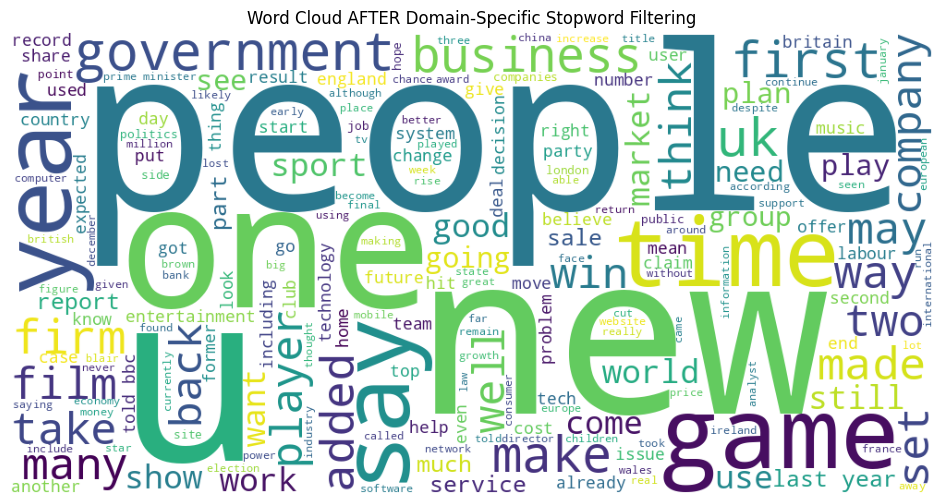

In [18]:
# ============================================================
# CELL 17: WORD CLOUD AFTER FILTERING
# ============================================================

text_after = " ".join(words_after_custom)

wordcloud_after = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text_after)

plt.figure(figsize=(12, 6))

plt.imshow(wordcloud_after)

plt.axis("off")

plt.title("Word Cloud AFTER Domain-Specific Stopword Filtering")

plt.show()



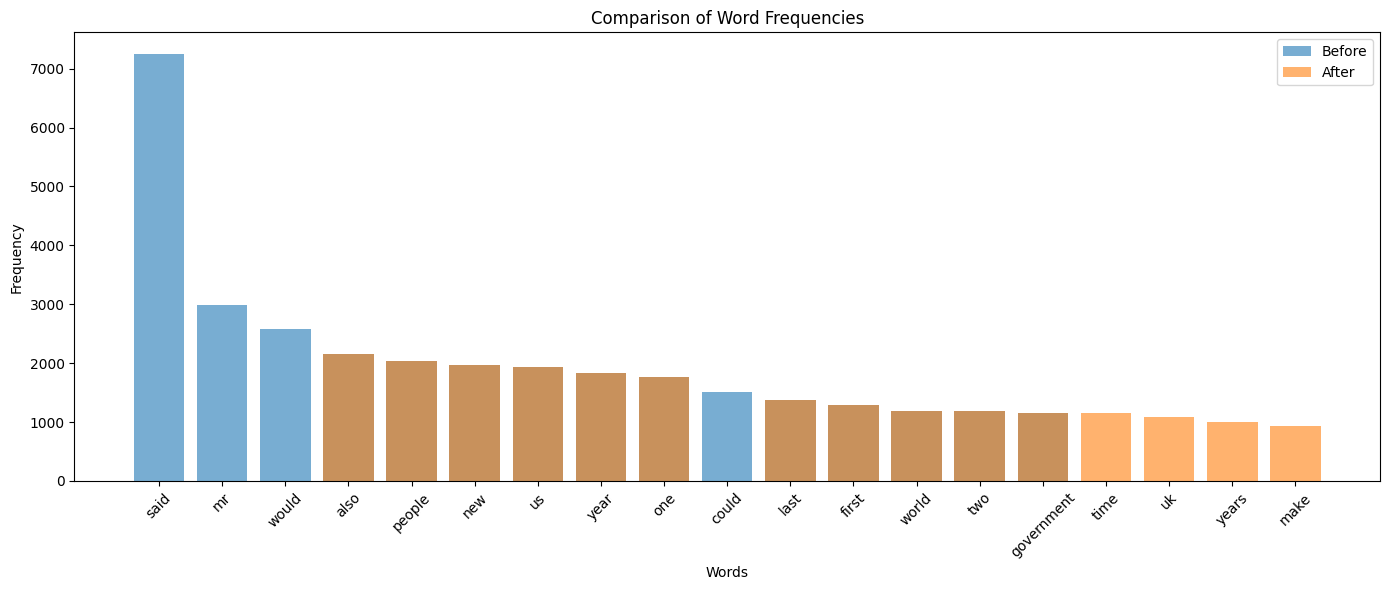

In [19]:

# ============================================================
# CELL 18: BAR CHART COMPARISON
# ============================================================

plt.figure(figsize=(14, 6))

plt.bar(
    df_before["Word"],
    df_before["Frequency"],
    alpha=0.6,
    label="Before"
)

plt.bar(
    df_after["Word"],
    df_after["Frequency"],
    alpha=0.6,
    label="After"
)

plt.title("Comparison of Word Frequencies")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()

plt.show()



In [21]:
# ============================================================
# CELL 20: HANDLE EMPTY INPUT
# ============================================================

# Initialize news_text to an empty string to prevent NameError
news_text = ""

# If the user does not enter text,
# use a sample news-style paragraph.

if news_text.strip() == "":

    news_text = """
    Prime Minister Narendra Modi visited New Delhi to discuss
    India's artificial intelligence and technology initiatives.
    The meeting included representatives from Google, Microsoft,
    Tata Consultancy Services and Infosys. Officials from the
    Government of India discussed opportunities for AI research,
    digital infrastructure and economic growth. The Prime Minister
    also highlighted the importance of Bengaluru, Hyderabad and
    Mumbai as major technology centres.
    """

    print("No text was entered.")
    print("Using sample text instead.")


# Display the text
print("\nText used for NER:")
print("-" * 60)
print(news_text)


No text was entered.
Using sample text instead.

Text used for NER:
------------------------------------------------------------

    Prime Minister Narendra Modi visited New Delhi to discuss
    India's artificial intelligence and technology initiatives.
    The meeting included representatives from Google, Microsoft,
    Tata Consultancy Services and Infosys. Officials from the
    Government of India discussed opportunities for AI research,
    digital infrastructure and economic growth. The Prime Minister
    also highlighted the importance of Bengaluru, Hyderabad and
    Mumbai as major technology centres.
    


In [22]:
# ============================================================
# CELL 21: APPLY spaCy NER
# ============================================================

# Process the text using spaCy
doc = nlp(news_text)

print("\nNamed Entities Found:")
print("-" * 60)

for entity in doc.ents:

    print(
        entity.text,
        " --> ",
        entity.label_
    )


# ============================================================
# CELL 22: CREATE ENTITY DATAFRAME
# ============================================================

# Store all detected entities
entity_data = []

for entity in doc.ents:

    entity_data.append({
        "Entity": entity.text,
        "Type": entity.label_
    })


# Convert to DataFrame
df_entities = pd.DataFrame(entity_data)

print("\nEntity Data:")
print("-" * 60)

if len(df_entities) > 0:
    print(df_entities.to_string(index=False))
else:
    print("No named entities were detected.")


# ============================================================
# CELL 23: COUNT ENTITY TYPES
# ============================================================

if len(df_entities) > 0:

    entity_type_frequency = Counter(
        df_entities["Type"]
    )

    df_entity_frequency = pd.DataFrame(
        entity_type_frequency.items(),
        columns=["Entity Type", "Frequency"]
    )

    # Sort by frequency
    df_entity_frequency = df_entity_frequency.sort_values(
        by="Frequency",
        ascending=True
    )

    print("\nEntity Frequency by Type")
    print("-" * 40)

    print(
        df_entity_frequency.to_string(index=False)
    )

else:

    df_entity_frequency = pd.DataFrame(
        columns=["Entity Type", "Frequency"]
    )




Named Entities Found:
------------------------------------------------------------
Narendra Modi  -->  PERSON
New Delhi  -->  GPE
India  -->  GPE
Google  -->  ORG
Microsoft  -->  ORG
Tata Consultancy Services  -->  ORG
Infosys  -->  ORG
the
    Government of India  -->  ORG
AI  -->  ORG
Bengaluru  -->  GPE
Hyderabad  -->  ORG
Mumbai  -->  GPE

Entity Data:
------------------------------------------------------------
                      Entity   Type
               Narendra Modi PERSON
                   New Delhi    GPE
                       India    GPE
                      Google    ORG
                   Microsoft    ORG
   Tata Consultancy Services    ORG
                     Infosys    ORG
the\n    Government of India    ORG
                          AI    ORG
                   Bengaluru    GPE
                   Hyderabad    ORG
                      Mumbai    GPE

Entity Frequency by Type
----------------------------------------
Entity Type  Frequency
     PERSON          

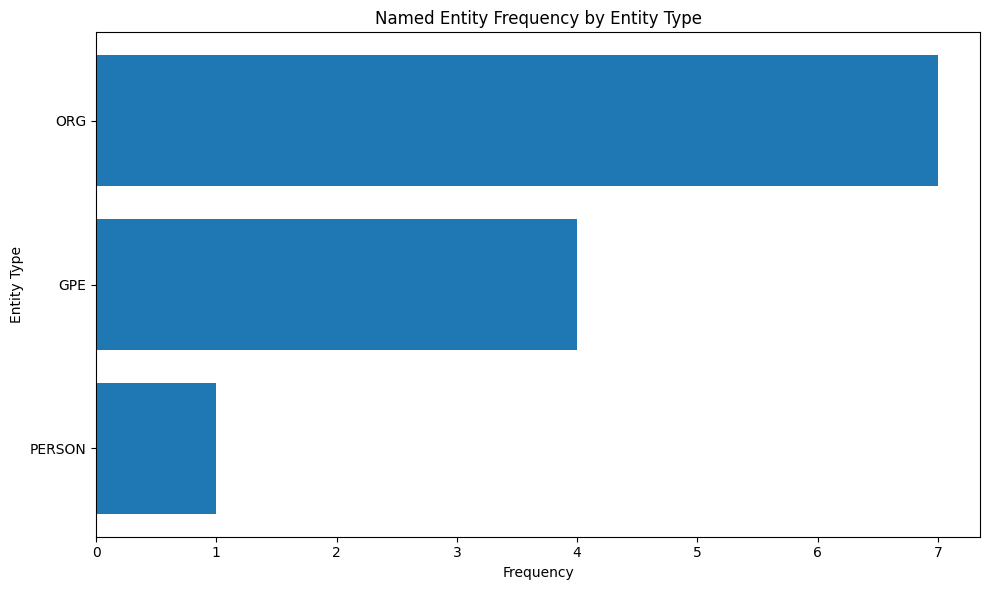


Important Entity Types
PERSON entities : 1
ORG entities    : 7
GPE/LOC entities: 4

 PERSON
----------------------------------------
Narendra Modi

 GPE
----------------------------------------
New Delhi
India
Bengaluru
Mumbai

 ORG
----------------------------------------
Google
Microsoft
Tata Consultancy Services
Infosys
the
    Government of India
AI
Hyderabad


In [23]:
# ============================================================
# CELL 24: HORIZONTAL BAR CHART
# ============================================================

if len(df_entity_frequency) > 0:

    plt.figure(figsize=(10, 6))

    plt.barh(
        df_entity_frequency["Entity Type"],
        df_entity_frequency["Frequency"]
    )

    plt.title("Named Entity Frequency by Entity Type")
    plt.xlabel("Frequency")
    plt.ylabel("Entity Type")

    plt.tight_layout()

    plt.show()

else:

    print("No entities available for plotting.")


# ============================================================
# CELL 25: SHOW IMPORTANT ENTITY TYPES
# ============================================================

print("\nImportant Entity Types")
print("=" * 50)

# Count specific entity categories
person_count = sum(
    1 for entity in doc.ents
    if entity.label_ == "PERSON"
)

organization_count = sum(
    1 for entity in doc.ents
    if entity.label_ == "ORG"
)

location_count = sum(
    1 for entity in doc.ents
    if entity.label_ in ["GPE", "LOC"]
)

print("PERSON entities :", person_count)
print("ORG entities    :", organization_count)
print("GPE/LOC entities:", location_count)


# ============================================================
# CELL 26: DISPLAY ENTITIES GROUPED BY TYPE
# ============================================================

# Dictionary to store entities according to their type
entities_by_type = {}

for entity in doc.ents:

    entity_type = entity.label_

    if entity_type not in entities_by_type:
        entities_by_type[entity_type] = []

    entities_by_type[entity_type].append(entity.text)


# Display grouped entities
for entity_type, entities in entities_by_type.items():

    print("\n", entity_type)
    print("-" * 40)

    for entity in entities:
        print(entity)


In [24]:
# ============================================================
# CELL 27: FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("NLP EXPERIMENT 4 - FINAL SUMMARY")
print("=" * 70)

print("\nTASK 1: Custom Corpus Ingestion")
print("Total Tokens:", total_tokens)
print("Unique Words:", unique_words)
print("Type-Token Ratio:", round(ttr, 4))

print("\nTASK 2: Domain-Specific Stopword Filtering")
print("Original words:", len(words_before_custom))
print("Filtered words:", len(words_after_custom))
print("Words removed:",
      len(words_before_custom) - len(words_after_custom))

print("\nTASK 3: Named Entity Recognition")

if len(df_entities) > 0:

    print("Total named entities detected:",
          len(df_entities))

    print("Different entity types detected:",
          len(df_entity_frequency))

else:

    print("No named entities detected.")

print("\nExperiment completed successfully!")



NLP EXPERIMENT 4 - FINAL SUMMARY

TASK 1: Custom Corpus Ingestion
Total Tokens: 840974
Unique Words: 27405
Type-Token Ratio: 0.0326

TASK 2: Domain-Specific Stopword Filtering
Original words: 470883
Filtered words: 456547
Words removed: 14336

TASK 3: Named Entity Recognition
Total named entities detected: 12
Different entity types detected: 3

Experiment completed successfully!
